Drew Pickett

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

Task 1

In [36]:
wine_data = load_wine(as_frame=True)
wine_df = wine_data.frame
wine_df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


Task 2

In [37]:
X_wine = wine_df.drop(columns='target')
scaler = StandardScaler()
X_wine_scaled = pd.DataFrame(scaler.fit_transform(X_wine), columns=X_wine.columns)

Task 3

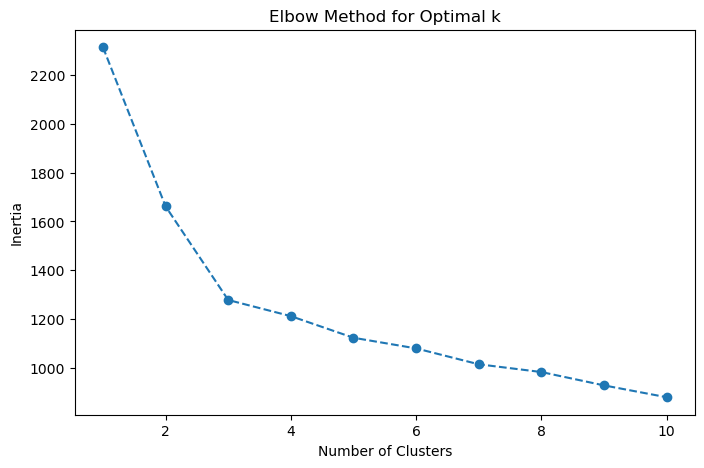

In [38]:
# Finding the optimal number of clusters using Elbow Method
inertia = []
k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_wine_scaled)
    inertia.append(kmeans.inertia_)

# Plot Elbow Method
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia, marker='o', linestyle='--')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()

Task 4

In [40]:
# Applying K-Means with k=3
kmeans = KMeans(n_clusters=3, random_state=42)
wine_df['Cluster'] = kmeans.fit_predict(X_wine_scaled)

Task 5

/var/folders/tv/k3f6m9fs11dg5nlz5dzw6xy00000gn/T/ipykernel_2505/378737732.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


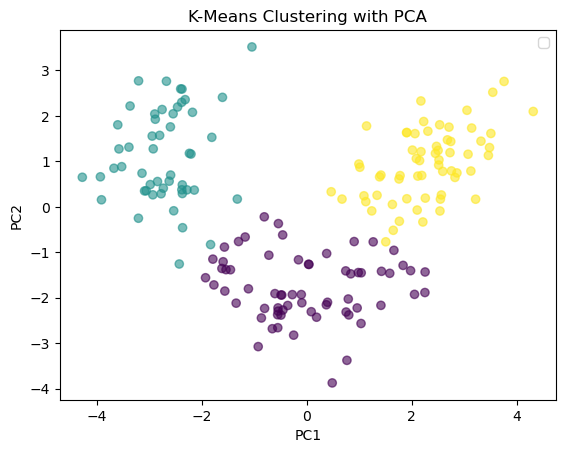

In [41]:
pca = PCA(n_components=2)
X_wine_scaled_pca = pd.DataFrame(pca.fit_transform(X_wine_scaled), columns=['PC1', 'PC2'])

# Scatter plot
plt.scatter(X_wine_scaled_pca.iloc[:, 0], X_wine_scaled_pca.iloc[:, 1], c=wine_df['Cluster'], cmap='viridis', alpha=0.6)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('K-Means Clustering with PCA')
plt.legend()
plt.show()

Task 6

1. How did you choose k?

- The inertia droped sharply from 1 to 3, the rate of decrease becomes insignificant after k = 3.

2. Did clusters appear well separated?

- Yes I believe their is significant clustering demonstrated in the k means clustering with pca visualization.

3. What challenges did you encounter?

- No major challenges to note.